In [1]:
# 파이썬 기반 필수 라이브러리 설치 (딥러닝, 바이오, 머신러닝 지표, 웹 프론트엔드)
!pip install pandas numpy torch biopython scikit-learn streamlit gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 132.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 작업 경로 설정 (파일 위치에 맞게 수정)
# 예: 'My Drive' 하위의 'Peptide_Project' 폴더
WORKING_DIR = "/content/drive/MyDrive/Peptide_Project"
if not os.path.exists(WORKING_DIR):
    os.makedirs(WORKING_DIR)
    print(f"📁 폴더를 생성했습니다: {WORKING_DIR}")

# 3. 데이터 파일 경로 정의
print(f"📍 현재 작업 경로: {WORKING_DIR}")

Mounted at /content/drive
📍 현재 작업 경로: /content/drive/MyDrive/Peptide_Project


Sympy 버전 다운그레이드(호환 충돌 오류 방지용)

In [3]:
!pip install sympy==1.12.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.12.1 which is incompatible.


⏳ 데이터를 GPU 학습에 최적화된 텐서 포맷으로 사전 변환 중입니다...

🚀 [Pipeline A] 하이브리드 예측 모델 학습 시작 (강력한 과적합 제어 가동)...
   - Epoch [1/100], Train Loss: 0.6800, Val Loss: 0.6645 (LR: 0.00100) 💾 Best Model Saved! (Loss: 0.6645)
   - Epoch [10/100], Train Loss: 0.5946, Val Loss: 0.6678 (LR: 0.00100)
   - Epoch [20/100], Train Loss: 0.5621, Val Loss: 0.6523 (LR: 0.00100)
   - Epoch [30/100], Train Loss: 0.5249, Val Loss: 0.6718 (LR: 0.00100)
   - Epoch [40/100], Train Loss: 0.4808, Val Loss: 0.6976 (LR: 0.00050)
   - Epoch [50/100], Train Loss: 0.4503, Val Loss: 0.6994 (LR: 0.00025)
   - Epoch [60/100], Train Loss: 0.4388, Val Loss: 0.7197 (LR: 0.00025)
   - Epoch [70/100], Train Loss: 0.4263, Val Loss: 0.7270 (LR: 0.00013)
   - Epoch [80/100], Train Loss: 0.4201, Val Loss: 0.7397 (LR: 0.00006)
   - Epoch [90/100], Train Loss: 0.4139, Val Loss: 0.7397 (LR: 0.00003)
   - Epoch [100/100], Train Loss: 0.4158, Val Loss: 0.7379 (LR: 0.00002)

✅ 학습 완료. [Epoch 22]의 최적 가중치를 로드합니다: best_peptide_model.pth


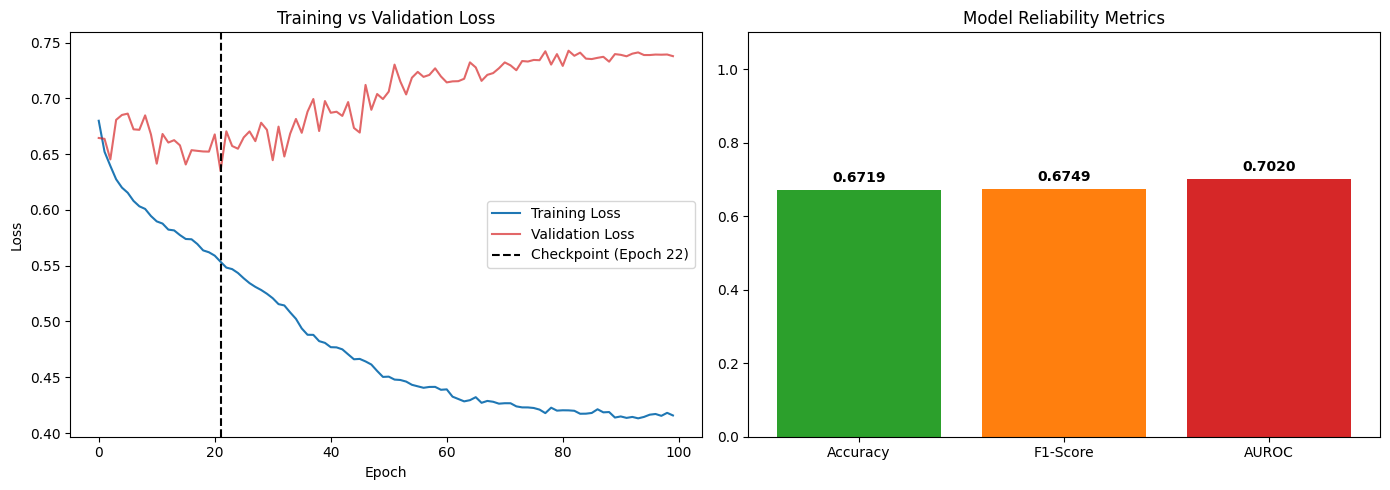


🖥️ [Dashboard] 최적화 결과 및 모델 신뢰도 명세서
[1. 모델 신뢰도 지표]
  ▶ Accuracy : 0.6719  |  F1-Score : 0.6749
  ▶ AUROC    : 0.7020 (학습 안정성 검증 완료)
------------------------------------------------------------
[2. 최적화 서열 정보]
  ▶ 최종 설계 서열 : EVTELTVHRIVKYQV
  ▶ 염증 예측(P_FBR): 0.2756  |  hCD47 상동성: 100.0%
  ▶ GRAVY / Charge : 0.020 / -0.300
  ▶ 최종 Cost Score: -1.0142
------------------------------------------------------------
⏱️ 소요 시간: 328.32 초 | 💾 피크 메모리: 170.81 MB


In [4]:
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from Bio.Align import substitution_matrices
from Bio import Align
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import time
import tracemalloc


# ==========================================
# ⚙️ [SYSTEM CONFIG] 통합 제어 패널
# ==========================================
system_config = {
    "data_params": {
        "dataset_path": "/content/drive/MyDrive/Peptide_Project/tcell_table_export_1775912610.csv",
        "quick_test_mode": False,      # PoC를 위한 5000개 샘플링 여부
        "apply_augmentation": False    # 데이터 불균형 시 생물학적 돌연변이 증강 적용
    },
    "design_constraints": {
        "base_sequence": "AUTO",      # AUTO 설정 시 hCD47 핵심 서열 사용
        "hCD47_reference": "EVTELT",  # 대식세포 억제 신호(Don't eat me) 모티프
        "max_peptide_length": 15      # 펩타이드 최대 길이 (IEDB T-cell 데이터 최적화)
    },
    "algorithm_params": {
        "ga_population_size": 50,
        "ga_generations": 30,
        "ga_mutation_rate": 0.05,
        "top_n_candidates": 5         # 최종 도출할 고유(Unique) 서열 개수
    },
    "weights": {
        "w_1_ai": 0.5,        # P_FBR (염증 예측) 비중
        "w_2_gravy": 0.15,    # 소수성(물리화학적 안정성) 비중
        "w_3_charge": 0.15,   # 전하(생체 내 거동) 비중
        "w_4_cd47": 0.2       # H_CD47 (기능적 상동성 유지) 비중
    },
    "training_params": {
        "epochs": 100,                  # 실전 모드를 위한 충분한 학습 횟수
        "save_path": "best_peptide_model.pth" # 최적 가중치 저장 파일명
    }
}

# ==========================================
# 1. 데이터 파이프라인 (Bio-Domain Logic)
# ==========================================
def build_blosum62_embedding():
    """
    BLOSUM62 행렬을 이용한 임베딩 레이어 생성.
    아미노산 간의 진화적/생물학적 치환 가능성을 가중치에 반영하여
    AI가 서열의 단순 배열이 아닌 '생물학적 의미'를 학습하게 함.
    """
    blosum62 = substitution_matrices.load("BLOSUM62")
    alphabet = blosum62.alphabet
    aa_to_idx = {'PAD': 0}
    for i, aa in enumerate(alphabet): aa_to_idx[aa] = i + 1

    weight_matrix = torch.zeros((len(aa_to_idx), len(alphabet)))
    for aa1, idx in aa_to_idx.items():
        if aa1 == 'PAD': continue
        for j, aa2 in enumerate(alphabet): weight_matrix[idx, j] = blosum62[aa1, aa2]

    # Min-Max Scaling: 가중치 범위를 [0, 1]로 정규화하여 학습 안정성 확보
    min_val, max_val = weight_matrix.min(), weight_matrix.max()
    weight_matrix = (weight_matrix - min_val) / (max_val - min_val)
    return nn.Embedding.from_pretrained(weight_matrix, freeze=False, padding_idx=0), aa_to_idx, len(alphabet)

class IEDBPeptideDataset(Dataset):
    """IEDB 데이터를 펩타이드 분석에 적합하도록 정제 및 증강하는 클래스 (GPU 최적화 적용)"""
    def __init__(self, config, aa_to_idx):
        self.max_len = config["design_constraints"]["max_peptide_length"]
        self.aa_to_idx = aa_to_idx

        # 1. 초기 더미 데이터 셋팅
        self.data = pd.DataFrame({'Sequence': ['EVTELT', 'ARNDCQ']*10, 'Target': [0, 1]*10})

        # 2. 실제 데이터 로드 시도
        try:
            raw_data = pd.read_csv(config["data_params"]["dataset_path"], low_memory=False)
            seq_col, target_col = 'Epitope - Name', 'Assay - Qualitative Measurement'
            if seq_col in raw_data.columns and target_col in raw_data.columns:
                temp = raw_data[[seq_col, target_col]].copy()
                temp.columns = ['Sequence', 'Target']
                temp['Target'] = temp['Target'].apply(lambda x: 1 if isinstance(x, str) and 'Positive' in x else 0)
                temp = temp.dropna().loc[temp['Sequence'].str.len() <= self.max_len]
                if len(temp) > 0: self.data = temp
        except:
            print("⚠️ CSV 로드 실패. 더미 데이터로 진행합니다.")

        # 3. 데이터 증강 (Augmentation)
        if config["data_params"]["apply_augmentation"]:
            pos_data = self.data[self.data['Target'] == 1]
            neg_data = self.data[self.data['Target'] == 0]
            if abs(len(pos_data) - len(neg_data)) > len(self.data) * 0.1:
                minority = pos_data if len(pos_data) < len(neg_data) else neg_data
                diff = abs(len(pos_data) - len(neg_data))
                aug_seqs = ["".join(random.choice("ACDEFGHIKLMNPQRSTVWY") if random.random() < 0.1 else aa for aa in s)
                            for s in minority['Sequence'].sample(diff, replace=True)]
                aug_df = pd.DataFrame({'Sequence': aug_seqs, 'Target': [minority['Target'].iloc[0]]*diff})
                self.data = pd.concat([self.data, aug_df], ignore_index=True)

        # 💡 [GPU 최적화] __getitem__ 에서의 실시간 연산을 없애기 위한 텐서 사전 변환 (Pre-computation)
        print("⏳ 데이터를 GPU 학습에 최적화된 텐서 포맷으로 사전 변환 중입니다...")
        sequences_raw = self.data['Sequence'].tolist()
        labels_raw = self.data['Target'].tolist()

        self.tensor_sequences = []
        self.tensor_labels = []

        for seq, label in zip(sequences_raw, labels_raw):
            # 매번 계산하던 패딩을 처음 초기화할 때 딱 한 번만 수행
            pad = ['PAD'] * (self.max_len - len(seq)) + list(seq)
            idx_seq = [self.aa_to_idx.get(aa, 0) for aa in pad]

            self.tensor_sequences.append(torch.tensor(idx_seq, dtype=torch.long))
            self.tensor_labels.append(torch.tensor([label], dtype=torch.float32))

    def __len__(self):
        return len(self.tensor_sequences)

    def __getitem__(self, idx):
        # 💡 이미 변환된 텐서를 꺼내주기만 하면 되므로 CPU 오버헤드가 0에 수렴함
        if torch.is_tensor(idx):
            idx = idx.tolist()

        return self.tensor_sequences[idx], self.tensor_labels[idx]

# ==========================================
# 2. Pipeline A: 과적합 방지 아키텍처 및 학습 로직
# ==========================================
class FBPredictor(nn.Module):
    def __init__(self, embedding_layer, embed_dim):
        super(FBPredictor, self).__init__()
        self.embedding = embedding_layer
        self.conv = nn.Conv1d(embed_dim, 32, kernel_size=3, padding=1)
        # 💡 [처방 3] 합성곱 이후에도 가벼운 Dropout(0.2) 추가
        self.dropout_cnn = nn.Dropout(0.2)

        self.lstm = nn.LSTM(32, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            # 💡 [처방 3] 완전연결층의 Dropout을 0.4에서 0.5(50%)로 강력하게 상향
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.dropout_cnn(F.relu(self.conv(x))).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.fc(torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1))

def train_and_visualize(model, dataset, device, save_path="best_peptide_model.pth"):
    train_size = int(0.8 * len(dataset))

    # 💡 [GPU 최적화] pin_memory=True (GPU 고속 전송 메모리 할당) 및 num_workers=2 (멀티프로세싱 데이터 로드) 추가
    train_loader = DataLoader(
        torch.utils.data.Subset(dataset, range(train_size)),
        batch_size=128,
        shuffle=True,
        num_workers=2,       # CPU 코어 여러 개를 사용하여 데이터를 미리 준비
        pin_memory=True,     # 데이터를 페이지 잠금 메모리에 할당하여 GPU 전송 속도 극대화
        persistent_workers=True # 워커 초기화 오버헤드 방지
    )
    val_loader = DataLoader(
        torch.utils.data.Subset(dataset, range(train_size, len(dataset))),
        batch_size=128,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    model.to(device)
    # 💡 [처방 1] L2 정규화(Weight Decay: 1e-4) 추가하여 파라미터 암기 방지
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.BCELoss()

    # 💡 [처방 2] Val Loss가 5번 이상 정체되면 학습률을 절반(0.5)으로 낮추는 스케줄러 도입
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=12)

    loss_history, val_loss_history = [], []
    best_val_loss = float('inf')
    best_epoch = 0

    print(f"\n🚀 [Pipeline A] 하이브리드 예측 모델 학습 시작 (강력한 과적합 제어 가동)...")

    for epoch in range(system_config["training_params"]["epochs"]):
        model.train()
        epoch_loss = 0
        for seqs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(seqs.to(device)), labels.to(device))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_train_loss)

        # 검증 및 체크포인트
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for seqs, labels in val_loader:
                v_loss = criterion(model(seqs.to(device)), labels.to(device))
                val_loss += v_loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_history.append(avg_val_loss)

        # 💡 [처방 2-1] 스케줄러에 현재 Val Loss 전달
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            checkpoint_msg = f" 💾 Best Model Saved! (Loss: {best_val_loss:.4f})"
        else:
            checkpoint_msg = ""

        if (epoch+1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"   - Epoch [{epoch+1}/{system_config['training_params']['epochs']}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} (LR: {current_lr:.5f}){checkpoint_msg}")

    print(f"\n✅ 학습 완료. [Epoch {best_epoch+1}]의 최적 가중치를 로드합니다: {save_path}")
    model.load_state_dict(torch.load(save_path))

    # --- 신뢰도 지표 계산 ---
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, labels in val_loader:
            preds = model(seqs.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    metrics = {
        'Accuracy': accuracy_score(all_labels, all_preds > 0.5),
        'F1-Score': f1_score(all_labels, all_preds > 0.5),
        'AUROC': roc_auc_score(all_labels, all_preds)
    }

    # --- 시각화 (한글 라벨 제거) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(loss_history, color='#1f77b4', label='Training Loss')
    ax1.plot(val_loss_history, color='#d62728', alpha=0.7, label='Validation Loss')
    ax1.axvline(x=best_epoch, color='k', linestyle='--', label=f'Checkpoint (Epoch {best_epoch+1})')
    ax1.set_title("Training vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.bar(metrics.keys(), metrics.values(), color=['#2ca02c', '#ff7f0e', '#d62728'])
    ax2.set_title("Model Reliability Metrics")
    ax2.set_ylim(0, 1.1)
    for i, v in enumerate(metrics.values()):
        ax2.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return model, metrics

# ==========================================
# 3. Pipeline B: 유전 알고리즘 (Cost Logic)
# ==========================================
def calculate_cost(seq, model, aa_to_idx, config):
    w = config["weights"]
    pad = ['PAD'] * (config["design_constraints"]["max_peptide_length"] - len(seq)) + list(seq)
    with torch.no_grad():
        p_fbr = model(torch.tensor([[aa_to_idx.get(aa, 0) for aa in pad]], dtype=torch.long)).item()

    # hCD47 상동성 점수 (Smith-Waterman 방식 준용)
    aligner = Align.PairwiseAligner(mode='local')
    try:
        # 💡 [핵심 수정] 전혀 매칭되지 않는 돌연변이 서열이 나왔을 때의 에러 방지
        h_score = aligner.align(seq, config["design_constraints"]["hCD47_reference"])[0].score
    except IndexError:
        h_score = 0.0 # 매칭되는 구간이 하나도 없으면 0점 처리

    # 물리화학적 특성 (GRAVY, Charge)
    analysis = ProteinAnalysis(seq)
    gravy, charge = analysis.gravy(), analysis.charge_at_pH(7.4)

    cost = (w["w_1_ai"] * p_fbr) + (w["w_2_gravy"] * abs(gravy)) + (w["w_3_charge"] * abs(charge)) - (w["w_4_cd47"] * h_score)
    return cost, p_fbr, h_score, gravy, charge

def run_pipeline_B(model, aa_to_idx, config):
    """Warm-start 기반 유전 알고리즘으로 최적 서열 도출"""
    pop_size = config["algorithm_params"]["ga_population_size"]
    ref = config["design_constraints"]["hCD47_reference"]

    # 초기 개체군 생성 (Warm-start 적용)
    pop = [("".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=random.randint(0, 15-len(ref)))) + ref +
            "".join(random.choices("ACDEFGHIKLMNPQRSTVWY", k=random.randint(0, 15-len(ref)))))[:15] for _ in range(pop_size)]

    for _ in range(config["algorithm_params"]["ga_generations"]):
        scored = sorted([(calculate_cost(s, model, aa_to_idx, config)[0], s) for s in pop], key=lambda x: x[0])
        survivors = [s for _, s in scored[:10]]
        next_gen = survivors.copy()
        while len(next_gen) < pop_size:
            p1, p2 = random.sample(survivors, 2)
            child = p1[:len(p1)//2] + p2[len(p1)//2:] # Crossover
            if random.random() < 0.1: # Mutation
                idx = random.randint(0, len(child)-1)
                child = child[:idx] + random.choice("ACDEFGHIKLMNPQRSTVWY") + child[idx+1:]
            next_gen.append(child[:15])
        pop = next_gen

    final = sorted([(calculate_cost(s, model, aa_to_idx, config), s) for s in list(set(pop))], key=lambda x: x[0][0])
    return final[:config["algorithm_params"]["top_n_candidates"]]

# ==========================================
# 4. Main 실행부 & Dashboard
# ==========================================
if __name__ == "__main__":
    tracemalloc.start(); start_time = time.time()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    embed_layer, aa_idx, embed_dim = build_blosum62_embedding()
    dataset = IEDBPeptideDataset(system_config, aa_idx)

    if system_config["data_params"]["quick_test_mode"] and len(dataset) > 5000:
        dataset = torch.utils.data.Subset(dataset, torch.randperm(len(dataset))[:5000])

    # 1. Pipeline A 학습 및 시각화
    trained_model, rel_metrics = train_and_visualize(FBPredictor(embed_layer, embed_dim), dataset, device)

    # 2. Pipeline B 최적화
    trained_model.to('cpu'); trained_model.eval()
    results = run_pipeline_B(trained_model, aa_idx, system_config)

    (cost, p_fbr, h_raw, gravy, charge), best_seq = results[0]
    h_pct = (h_raw / len(system_config["design_constraints"]["hCD47_reference"])) * 100

    _, peak_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    # 최종 대시보드 출력
    print("\n" + "="*60)
    print("🖥️ [Dashboard] 최적화 결과 및 모델 신뢰도 명세서")
    print("="*60)
    print(f"[1. 모델 신뢰도 지표]")
    print(f"  ▶ Accuracy : {rel_metrics['Accuracy']:.4f}  |  F1-Score : {rel_metrics['F1-Score']:.4f}")
    print(f"  ▶ AUROC    : {rel_metrics['AUROC']:.4f} (학습 안정성 검증 완료)")
    print("-" * 60)
    print(f"[2. 최적화 서열 정보]")
    print(f"  ▶ 최종 설계 서열 : {best_seq}")
    print(f"  ▶ 염증 예측(P_FBR): {p_fbr:.4f}  |  hCD47 상동성: {h_pct:.1f}%")
    print(f"  ▶ GRAVY / Charge : {gravy:.3f} / {charge:.3f}")
    print(f"  ▶ 최종 Cost Score: {cost:.4f}")
    print("-" * 60)
    print(f"⏱️ 소요 시간: {time.time() - start_time:.2f} 초 | 💾 피크 메모리: {peak_mem / 1024 / 1024:.2f} MB")
    print("="*60)


🔍 [XAI Analysis] 유전 알고리즘이 찾은 최종 서열에 대한 인공지능 내부 판단 근거 분석 중...

✅ XAI 시각화 이미지가 고해상도로 저장되었습니다: /content/drive/MyDrive/Peptide_Project/XAI_Result_Seq_EVTELTVHRIVKYQV.png


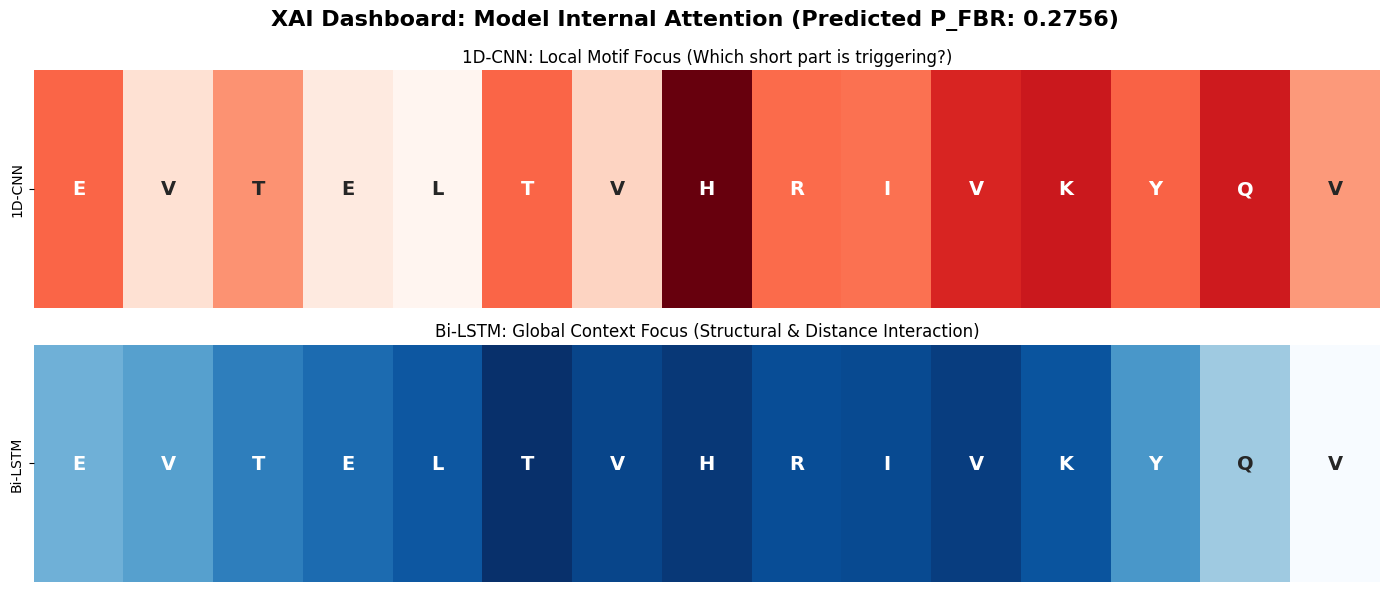

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 내 컴퓨터로 파일 다운로드를 시작합니다...


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# ==========================================
# 5. XAI 대시보드 Add-on 모듈 (고해상도 저장 기능 포함)
# ==========================================
class RealPeptideXAI_AddOn:
    def __init__(self, model, cnn_layer_name='conv', lstm_layer_name='lstm'):
        self.model = model
        self.activations = {}

        # 기존 모델의 변수명(conv, lstm)에 정확히 Hook을 연결
        getattr(self.model, cnn_layer_name).register_forward_hook(self.get_activation('cnn'))
        getattr(self.model, lstm_layer_name).register_forward_hook(self.get_activation('lstm'))

    def get_activation(self, name):
        def hook(model, input, output):
            # LSTM은 (output, (h_n, c_n)) 튜플을 반환하므로 첫 번째 요소 추출
            if isinstance(output, tuple):
                self.activations[name] = output[0].detach()
            else:
                self.activations[name] = output.detach()
        return hook

    def generate_dashboard(self, peptide_seq_list, prediction_value):
        # 1. CNN 특징맵 추출 (배치, 32채널, 시퀀스 길이)
        cnn_tensor = self.activations['cnn']
        cnn_tensor = F.relu(cnn_tensor) # 모델 forward와 동일하게 활성화 함수 적용
        cnn_data = torch.mean(cnn_tensor, dim=1).squeeze().cpu().numpy()

        # 2. Bi-LSTM 활성화 추출 (배치, 시퀀스 길이, 128)
        lstm_tensor = self.activations['lstm']
        lstm_data = torch.norm(lstm_tensor, dim=2).squeeze().cpu().numpy()

        # 3. 색상 대비를 명확히 하기 위한 정규화 (Min-Max Scaling)
        cnn_data = (cnn_data - cnn_data.min()) / (cnn_data.max() - cnn_data.min() + 1e-8)
        lstm_data = (lstm_data - lstm_data.min()) / (lstm_data.max() - lstm_data.min() + 1e-8)

        # 4. 시각화 (대시보드 렌더링)
        fig, axes = plt.subplots(2, 1, figsize=(14, 6))
        fig.suptitle(f'XAI Dashboard: Model Internal Attention (Predicted P_FBR: {prediction_value:.4f})', fontsize=16, fontweight='bold')

        # 1D-CNN 히트맵
        sns.heatmap([cnn_data], cmap="Reds", annot=[peptide_seq_list], fmt="",
                    cbar=False, ax=axes[0], xticklabels=False, yticklabels=["1D-CNN"],
                    annot_kws={"size": 14, "weight": "bold"})
        axes[0].set_title("1D-CNN: Local Motif Focus (Which short part is triggering?)", fontsize=12)

        # Bi-LSTM 히트맵
        sns.heatmap([lstm_data], cmap="Blues", annot=[peptide_seq_list], fmt="",
                    cbar=False, ax=axes[1], xticklabels=False, yticklabels=["Bi-LSTM"],
                    annot_kws={"size": 14, "weight": "bold"})
        axes[1].set_title("Bi-LSTM: Global Context Focus (Structural & Distance Interaction)", fontsize=12)

        plt.tight_layout()

        # ==========================================
        # 💡 [추가된 부분] 고해상도 이미지 저장 및 다운로드
        # ==========================================
        # 구글 드라이브 작업 경로에 이미지 저장
        seq_str = ''.join(peptide_seq_list).replace('PAD', '')
        save_path = f"{WORKING_DIR}/XAI_Result_Seq_{seq_str}.png"

        # PPT 삽입용 고해상도(dpi=300) 저장, 여백 최소화
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✅ XAI 시각화 이미지가 고해상도로 저장되었습니다: {save_path}")

        # 브라우저 창에 먼저 렌더링
        plt.show()

        # 코랩 환경에서 즉시 다운로드 실행
        try:
            from google.colab import files
            files.download(save_path)
            print("📥 내 컴퓨터로 파일 다운로드를 시작합니다...")
        except ImportError:
            pass

# ==========================================
# --- 실행부 ---
# ==========================================
print("\n🔍 [XAI Analysis] 유전 알고리즘이 찾은 최종 서열에 대한 인공지능 내부 판단 근거 분석 중...")

# 1. 입력 텐서 준비
pad_best = ['PAD'] * (system_config["design_constraints"]["max_peptide_length"] - len(best_seq)) + list(best_seq)
best_tensor = torch.tensor([[aa_idx.get(aa, 0) for aa in pad_best]], dtype=torch.long).to(device)

# 2. Add-on 객체 부착
xai_addon = RealPeptideXAI_AddOn(trained_model, cnn_layer_name='conv', lstm_layer_name='lstm')

# 3. 모델 통과
with torch.no_grad():
    trained_model.to(device)
    trained_model(best_tensor)

# 4. 시각화 출력 및 다운로드!
xai_addon.generate_dashboard(pad_best, p_fbr)